# Single-qubit calibration (co-simulation)

The co-sim analogue of the hardware `Calibration_X6Y3` notebook. Instead of a real qubit we
drive the Verilated `PulseTableSoc` against a `TwoLevelModel` with **planted ground truth**
(`f_ge`, Rabi rate, T1, T2), start from a **deliberately-detuned `Config`**, and run the
`Calibration_X6Y3` flow one experiment per cell:

> ReadoutCalibration → Separation → Fidelity → ReadoutFidelity → Frequency →
> Amplitude (coarse) → Amplitude (fine) → Phase

Each cell is `r = Cal(...).run(drv); r.apply()`; we watch the `Config` move toward the
planted truth. The notebook owns the sim lifecycle (`server.start` … `server.stop`).

In [1]:
import math
from pathlib import Path

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import riscq
from riscq.cal import (Config, ReadoutCalibration, Separation, Fidelity, ReadoutFidelity,
                       Frequency, Amplitude, Phase)
from riscq.cal.base import gate_sigma, seconds, GATE_ENV
from riscq.map import SocMap, SocParams
from riscq.pulses import Pulse, units
from riscq.sim import server

SW = Path(riscq.__file__).resolve().parents[1]   # .../software (robust to the notebook cwd)
F_GE = 50e6                                       # planted qubit frequency

## Bring up the co-sim and derive the SocMap

In [2]:
drv = server.start(SW / 'configs' / 'sim-2q.json', SW / 'build' / 'sim-2q')
m = SocMap(SocParams.from_json(drv.sim.get_params()))
print('cosim up; qubits =', m.params.qubit_num)

cosim up; qubits = 2


## Plant the ground truth

A `TwoLevelModel` on core 0 with a Rabi rate set to ~1.5 Rabi periods across a full-scale
amplitude sweep, plus T1/T2 and a little readout shot noise. We record the *true* X90
amplitude (the amplitude that rotates by exactly π/2) so we can score the calibration.

In [3]:
x90_full = Pulse(GATE_ENV, freq_hz=F_GE, amp=0.5)
sig_max = gate_sigma(m, x90_full, F_GE, units.AMP_SCALE - 600)   # drive integral at full scale
rabi = float(3 * math.pi / sig_max)                             # ~1.5 Rabi periods over the sweep

# A projective TwoLevelModel on core 0 (collapse=True — counts mode needs a sampled shot, spec 08).
# The readout budget matters: the qcal SNR classifier (spec 13 Q2) needs relax >> T1 >> SEP so the
# |1> prep still stands at readout yet the idle head fully resets to |0> — at t1=300/relax=1600 the
# T1 decay across the SEP makes the |1> cluster bimodal and separation stalls below 1.0. t1=600 keeps
# the clusters clean (spec 13 Q6).
drv.sim.set_model(dict(kind='twolevel', core=0, rabi_rad_per_amp=rabi, readout_code=2048,
                       readout_amp=20000.0, readout_phase=0.0, f_ge=F_GE,
                       t1=600, t2=3000, noise_scale=300.0, noise_seed=11, collapse=True))

g = sig_max / (units.AMP_SCALE - 600)                          # drive per amp code (linear)
true_x90_amp = (math.pi / 2) / (rabi * g) / units.AMP_SCALE     # amp that gives a pi/2 rotation
print(f'planted rabi={rabi:.3e} rad/amp   true X90 amp~{true_x90_amp:.4f}')

planted rabi=7.416e-05 rad/amp   true X90 amp~0.1616


## A deliberately-detuned starting Config

The drive carrier is off `f_ge` by `d0_code` codes and the X90 amplitude is wrong (0.5 vs
the true ≈0.16). The calibrations must pull both back.

In [4]:
def _s(nb):                                   # batches -> seconds for this build (Config units)
    return seconds(nb, m)

d0_code = 60
drive = units.code_to_freq(units._freq_code(F_GE, m.params) + d0_code, m.params)

# The Config is qcal-style slash paths in PHYSICAL units (Hz, seconds, normalized amp) — spec 13 Q0.
# (Config.from_qcal(path) loads a real qcal config.yaml into the same paths; here we build the
# co-sim-scaled one by hand so every number is visible.)
cfg = Config()
cfg['qubit/0/freq'] = float(drive)            # off f_ge by d0_code
cfg['qubit/0/x90/amp'] = 0.5                  # wrong (true ~ 0.16)
cfg['qubit/0/T1'] = _s(600)
cfg['readout/0/freq'] = float(units.demod_code_to_freq(2048, m.params))
cfg['readout/0/amp'] = 0.5                    # the readout-drive power Fidelity sweeps
cfg['readout/0/dur'] = _s(56)                 # readout DRIVE length (covers the window + SEP)
cfg['readout/0/demod/dur'] = _s(40)           # the integration WINDOW
cfg['reset/relax'] = _s(3200)                 # idle head >> T1 (the readout budget)

freq_err0 = abs(cfg['qubit/0/freq'] - F_GE)
amp_err0 = abs(cfg['qubit/0/x90/amp'] - true_x90_amp)
print(f'start: freq err={freq_err0:.3g} Hz   X90 amp err={amp_err0:.4f}')

def apply_if_ok(r):
    '''Print the step; apply its proposal only if the fit succeeded (a failed fit refuses).'''
    print(f'{r.label}: ok={r.ok}  proposal={r.proposal}')
    if r.ok:
        r.apply()
    else:
        print('  fit failed — Config left unchanged')
    return r

start: freq err=1.46e+06 Hz   X90 amp err=0.3384


## Readout calibration

Train the |0⟩/|1⟩ IQ classifier (ReadoutCalibration), then find the readout (demod) frequency (Separation, the two-state cluster SNR), the readout drive amplitude (Fidelity), and the assignment-fidelity confusion matrix (ReadoutFidelity, straight off the on-chip `res` bit).

ReadoutCalibration [0]: ok=True  proposal={'readout/0/demod/phase': 1.5854577074740488, 'readout/0/res_sign': 1}


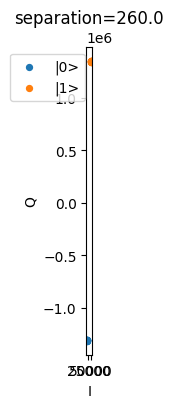

In [5]:
rc = apply_if_ok(ReadoutCalibration(cfg, 0, shots=12).run(drv))
iq0, iq1 = rc.data[0]['iq0'], rc.data[0]['iq1']    # data is per-qubit: r.data[q] (spec 13 Q5)
plt.figure(figsize=(4, 4))
plt.scatter(iq0[:, 0], iq0[:, 1], label='|0>', s=18)
plt.scatter(iq1[:, 0], iq1[:, 1], label='|1>', s=18)
plt.gca().set_aspect('equal'); plt.legend(); plt.title(f"separation={rc.data[0]['separation']:.1f}")
plt.xlabel('I'); plt.ylabel('Q'); plt.show()

Separation [0]: ok=True  proposal={'readout/0/freq': 12500000.0}


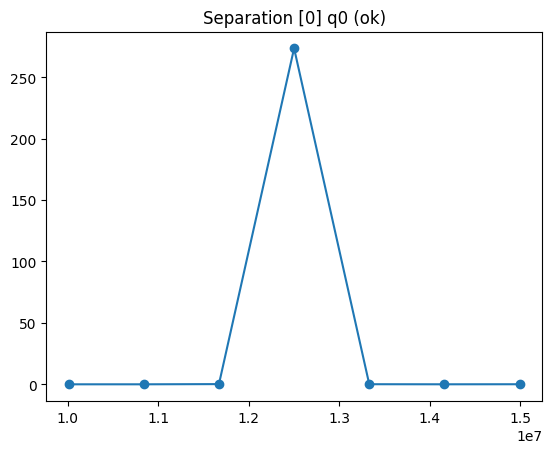

readout/0/freq -> 1.25e+07 Hz


In [6]:
sep = apply_if_ok(Separation(cfg, 0, span=2.5e6, points=7, shots=10).run(drv))
sep.plot(); plt.show()
print(f"readout/0/freq -> {cfg['readout/0/freq']:.4g} Hz")

In [7]:
fid = apply_if_ok(Fidelity(cfg, 0, amp_span=0.005, points=5, shots=10).run(drv))  # readout AMP
rf = apply_if_ok(ReadoutFidelity(cfg, 0, shots=16).run(drv))
print('readout amp ->', round(cfg['readout/0/amp'], 4))
print('confusion matrix (row=prepared, col=classified):')
print(np.round(rf.data[0]['confusion'], 3), ' fidelity=', round(rf.data[0]['fidelity'], 3))

Fidelity [0]: ok=True  proposal={'readout/0/amp': 0.49502412545235225}


ReadoutFidelity [0]: ok=True  proposal={'readout/0/fidelity': 0.96875}
readout amp -> 0.495
confusion matrix (row=prepared, col=classified):
[[1.    0.   ]
 [0.062 0.938]]  fidelity= 0.969


## Qubit calibration

Ramsey-vs-detuning recovers the drive frequency; a coarse then fine (repeated-pulse)
Amplitude sweep sets the X90 amplitude; Phase checks the X90 axis error.

In [8]:
fr = apply_if_ok(Frequency(cfg, 0, points=9, shots=40).run(drv))
print(f"recovered qubit/0/freq -> {fr.proposal.get('qubit/0/freq', float('nan')):.6g} Hz "
      f"(planted {F_GE:g})")
print(f"qubit/0/freq err: {freq_err0:.3g} -> {abs(cfg['qubit/0/freq'] - F_GE):.3g} Hz")

Frequency [0]: ok=True  proposal={'qubit/0/freq': 49966154.23312322}
recovered qubit/0/freq -> 4.99662e+07 Hz (planted 5e+07)
qubit/0/freq err: 1.46e+06 -> 3.38e+04 Hz


/config/build/agentic-rv-dev/software/riscq/cal/fits.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=list(p0), maxfev=20000)


Amplitude [0] X90 n_gates=1: ok=True  proposal={'qubit/0/x90/amp': 0.1633659849351381, 'qubit/0/rabi': 7.339714796346987e-05}


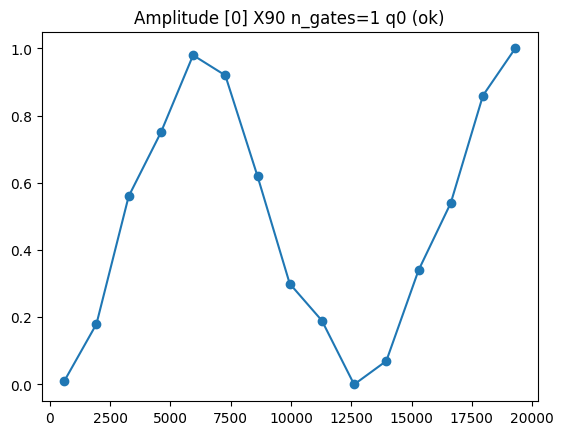

coarse X90 amp -> 0.1634  (true~0.1616)


In [9]:
# coarse Rabi (cosine): 15 points over the full amp range so the FFT seed locks the right period
# (too few points aliases to a harmonic -> half the true amp).
ac = apply_if_ok(Amplitude(cfg, 0, n_gates=1, points=15, shots=100).run(drv))
ac.plot(); plt.show()
print(f"coarse X90 amp -> {cfg['qubit/0/x90/amp']:.4f}  (true~{true_x90_amp:.4f})")

In [10]:
# fine pass: 4 repeated X90s amplify the amplitude error; relative_amp sweeps 0.7-1.3x the
# current amp (spec 13 Q4 — no more amp_codes array). Needs the coarse amp to be right (the window
# is relative to it).
af = apply_if_ok(Amplitude(cfg, 0, n_gates=4, amp_span=(0.7, 1.3), relative_amp=True,
                           points=13, shots=64).run(drv))
print(f"fine X90 amp -> {cfg['qubit/0/x90/amp']:.4f}  (true~{true_x90_amp:.4f})")

Amplitude [0] X90 n_gates=4: ok=True  proposal={'qubit/0/x90/amp': 0.16313248560514954}
fine X90 amp -> 0.1631  (true~0.1616)


In [11]:
ph = apply_if_ok(Phase(cfg, 0, points=7, shots=32, relative_phase=True).run(drv))
vz = cfg.get('qubit/0/x90/vz', [0.0, 0.0])     # Phase calibrates the virtual-Z pair (spec 13 Q3)
print(f"X90 virtual-Z -> {vz[0]:+.4f} rad  (planted 0)")

Phase [0]: ok=True  proposal={'qubit/0/x90/vz': [0.02960032358207794, 0.02960032358207794]}
X90 virtual-Z -> +0.0296 rad  (planted 0)


## Summary — the Config converged toward the planted truth

In [12]:
freq_err1 = abs(cfg['qubit/0/freq'] - F_GE)
amp_err1 = abs(cfg['qubit/0/x90/amp'] - true_x90_amp)
print(f'qubit freq  err: {freq_err0:10.3g} -> {freq_err1:10.3g} Hz')
print(f'X90 amp     err: {amp_err0:10.4f} -> {amp_err1:10.4f}')
print(f'X90 amp: {cfg["qubit/0/x90/amp"]:.4f}  (planted true ~ {true_x90_amp:.4f})')
assert freq_err1 < freq_err0 and amp_err1 < amp_err0, 'calibration did not improve the Config'
print('\nOK — both the frequency and the X90 amplitude improved.')

qubit freq  err:   1.46e+06 ->   3.38e+04 Hz
X90 amp     err:     0.3384 ->     0.0015
X90 amp: 0.1631  (planted true ~ 0.1616)

OK — both the frequency and the X90 amplitude improved.


## Tear down the co-sim

In [13]:
drv.sim.set_model({'kind': 'zero'})
server.stop(drv)
print('cosim stopped')

cosim stopped
